In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

train_path = Path("../data/processed/train.jsonl")
valid_path = Path("../data/processed/valid.jsonl")

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

train_df = load_jsonl(train_path)
valid_df = load_jsonl(valid_path)

train_df["split"] = "train"
valid_df["split"] = "valid"
df = pd.concat([train_df, valid_df], ignore_index=True)

df.head()

,src,trg,split
0,I enjoyed reading about your dreams,tôi rất thích đọc về những giấc mơ của bạn,train
1,Say your prayers before you eat.,nói lời cầu nguyện của bạn trước khi bạn ăn.,train
2,Do you not want to know who has taken it?,bạn không muốn biết ai đã lấy nó?,train
3,I caught my finger in the door.,tôi bắt ngón tay của tôi trong cửa.,train
4,Can I ride this horse for a long time?,Tôi có thể cưỡi con ngựa này trong một thời gi...,train


In [2]:
summary = df["split"].value_counts().reset_index()
summary.columns = ["split", "samples"]
summary["percent"] = summary["samples"] / summary["samples"].sum() * 100
summary

,split,samples,percent
0,train,228681,90.0
1,valid,25409,10.0


In [3]:
for col in ["src", "trg"]:
    df[f"{col}_chars"] = df[col].fillna("").astype(str).str.len()
    df[f"{col}_words"] = df[col].fillna("").astype(str).str.split().str.len()

df.groupby("split")[["src_words", "trg_words", "src_chars", "trg_chars"]].describe()

src_words                                               trg_words  \
          count      mean       std  min  25%  50%  75%   max     count   
split                                                                     
train  228681.0  6.774402  2.699506  1.0  5.0  6.0  8.0  47.0  228681.0   
valid   25409.0  6.766815  2.728241  1.0  5.0  6.0  8.0  44.0   25409.0   

                 ... src_chars        trg_chars                             \
           mean  ...       75%    max     count       mean        std  min   
split            ...                                                         
train  8.350969  ...      41.0  261.0  228681.0  34.755065  15.058554  1.0   
valid  8.342674  ...      41.0  227.0   25409.0  34.708253  15.101739  5.0   

                                
        25%   50%   75%    max  
split                           
train  24.0  32.0  43.0  259.0  
valid  24.0  32.0  43.0  270.0  

[2 rows x 32 columns]

In [4]:
# lấy p95 của trg_words để xem độ dài tối đa của câu dịch
trg_words_p95 = df["trg_words"].quantile(0.95)
print(f"95th percentile of trg_words: {trg_words_p95}")

# lấy p95 của src_words để xem độ dài tối đa của câu dịch
src_words_p95 = df["src_words"].quantile(0.95)
print(f"95th percentile of src_words: {src_words_p95}")

95th percentile of trg_words: 15.0
95th percentile of src_words: 12.0


In [5]:
df.groupby("split")[["src", "trg"]].apply(lambda x: x.isna().sum())

,src,trg
split,,
train,0,0
valid,0,0


In [6]:
pd.DataFrame({
    "metric": ["duplicate_src", "duplicate_trg", "duplicate_pair"],
    "train": [
        train_df.duplicated("src").sum(),
        train_df.duplicated("trg").sum(),
        train_df.duplicated(["src", "trg"]).sum(),
    ],
    "valid": [
        valid_df.duplicated("src").sum(),
        valid_df.duplicated("trg").sum(),
        valid_df.duplicated(["src", "trg"]).sum(),
    ],
})

,metric,train,valid
0,duplicate_src,8,0
1,duplicate_trg,8365,136
2,duplicate_pair,8,0


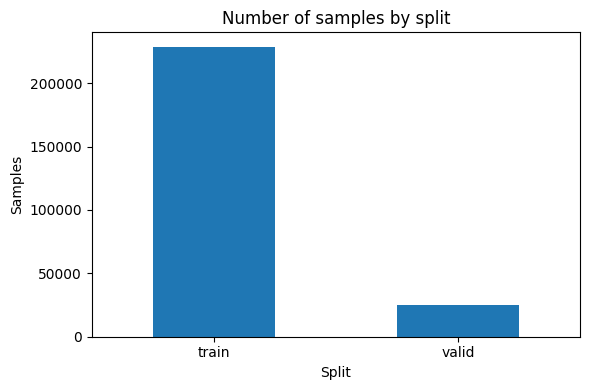

In [7]:
df["split"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Number of samples by split")
plt.xlabel("Split")
plt.ylabel("Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

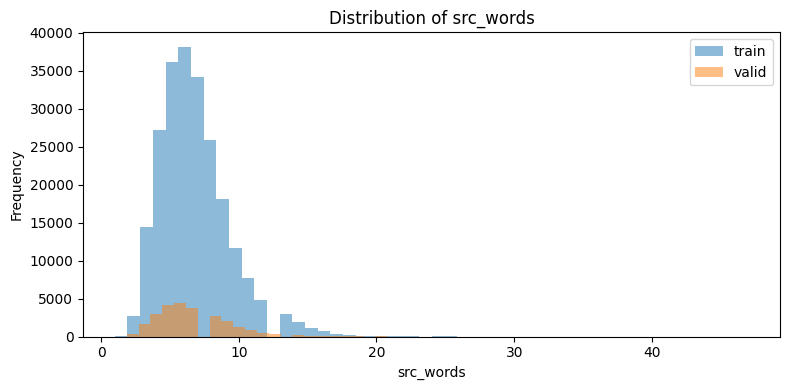

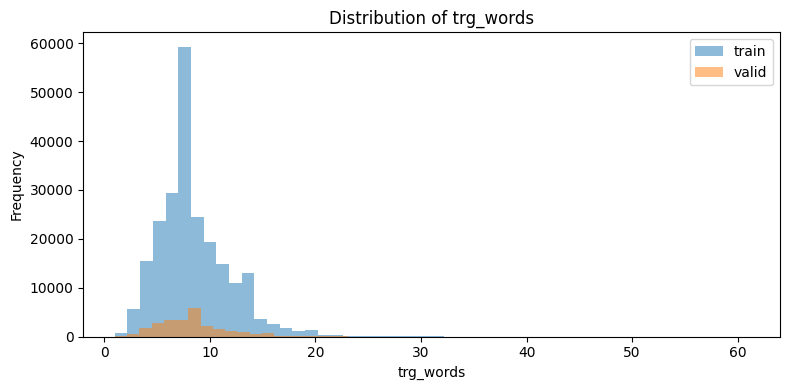

In [8]:
for col in ["src_words", "trg_words"]:
    plt.figure(figsize=(8,4))
    for split in ["train", "valid"]:
        df[df["split"] == split][col].plot(
            kind="hist", bins=50, alpha=0.5, label=split
        )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

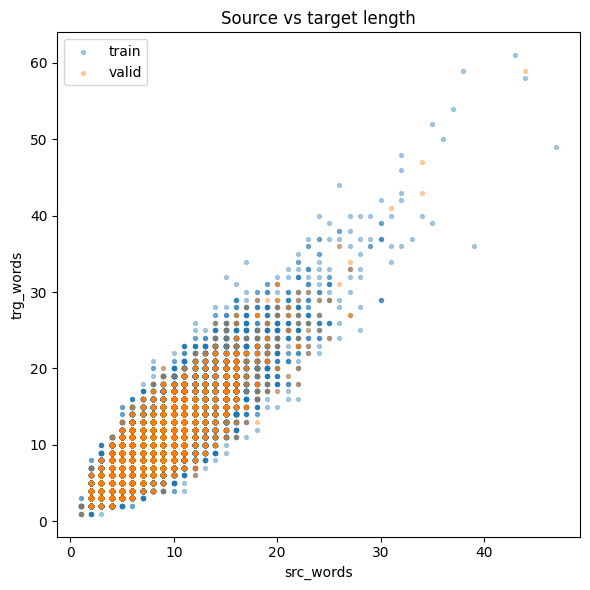

In [9]:
plt.figure(figsize=(6,6))

for split in ["train", "valid"]:
    sub = df[df["split"] == split]
    plt.scatter(sub["src_words"], sub["trg_words"], s=8, alpha=0.35, label=split)

plt.title("Source vs target length")
plt.xlabel("src_words")
plt.ylabel("trg_words")
plt.legend()
plt.tight_layout()
plt.show()